# Assignment 3 Synthetic Data Generation

AKARSH DUBEY         (CS25MTECH14001)             
ATISH KADAM          (CS25MTECH14003)

**Environment setup and importing required packages**

In [ ]:
!rm -rf /content/*

In [ ]:
import sys, os

! pip install -q pandas numpy scikit-learn matplotlib seaborn scipy tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from scipy import stats as sp_stats
from scipy.stats import ks_2samp, levene

print("TensorFlow :", tf.__version__)
print("NumPy      :", np.__version__)
print("Pandas     :", pd.__version__)

TensorFlow : 2.19.0
NumPy      : 2.0.2
Pandas     : 2.2.2


**Loading Dataset and its Format**

In [ ]:
import pandas as pd
from google.colab import files
uploaded = files.upload()
csv_path = list(uploaded.keys())[0]
df = pd.read_csv(csv_path)

print(f"Loaded from : {csv_path}")
print(f"Shape       : {df.shape}")
display(df.head(3))

Saving customer_transactions_1500 - customer_transactions_1500.csv to customer_transactions_1500 - customer_transactions_1500.csv
Loaded from : customer_transactions_1500 - customer_transactions_1500.csv
Shape       : (1500, 8)


,age,gender,city,annual_income,product_category,purchase_amount,payment_method,is_returned
0,58,Female,Houston,44592,Clothing,19.85,Debit Card,True
1,61,Male,San Jose,127080,Sports,1136.52,Credit Card,True
2,23,Other,New York,58657,Beauty,145.47,Debit Card,False


**Pre-processing loaded datasets**

In [ ]:
# Numeric columns  → median imputation → StandardScaler
# Categorical cols → mode imputation  → OneHotEncoder
# Final tensor     = [scaled_numeric | OHE_categorical]  (float32)

NUMERIC_COLS     = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
CATEGORICAL_COLS = df.select_dtypes(exclude=['int64', 'float64']).columns.tolist()

print("Numeric     :", NUMERIC_COLS)
print("Categorical :", CATEGORICAL_COLS)

df_proc = df.copy()
for col in NUMERIC_COLS:
    df_proc[col].fillna(df_proc[col].median(), inplace=True)
for col in CATEGORICAL_COLS:
    df_proc[col].fillna(df_proc[col].mode()[0], inplace=True)

scaler = StandardScaler()
X_num  = scaler.fit_transform(df_proc[NUMERIC_COLS]).astype(np.float32)

try:
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
except TypeError:
    ohe = OneHotEncoder(sparse=False, handle_unknown='ignore')

X_cat     = ohe.fit_transform(df_proc[CATEGORICAL_COLS]).astype(np.float32)
cat_sizes = [len(c) for c in ohe.categories_]

X_full    = np.concatenate([X_num, X_cat], axis=1)
N_NUMERIC = len(NUMERIC_COLS)
INPUT_DIM = X_full.shape[1]

print(f"\nNumeric block  : {X_num.shape[1]} features")
print(f"Categorical OHE: {X_cat.shape[1]} features  "
      f"(sizes: {dict(zip(CATEGORICAL_COLS, cat_sizes))})")
print(f"Total input dim: {INPUT_DIM}")

Numeric     : ['age', 'annual_income', 'purchase_amount']
Categorical : ['gender', 'city', 'product_category', 'payment_method', 'is_returned']

Numeric block  : 3 features
Categorical OHE: 24 features  (sizes: {'gender': 3, 'city': 10, 'product_category': 5, 'payment_method': 4, 'is_returned': 2})
Total input dim: 27


**Deciding Hyperparameters**

In [ ]:
LATENT_DIM       = 16
HIDDEN_DIM       = 128
EPOCHS           = 300
BATCH_SIZE       = 64
LR               = 1e-3
BETA_FINAL       = 0.1
KL_WARMUP_EPOCHS = 90
NUMERIC_WEIGHT   = 3.0
PURCHASE_BOOST   = 3.0
TEMPERATURE      = 2.0

N_SYNTHETIC = len(df)

num_col_weights = np.ones(N_NUMERIC, dtype=np.float32)
if 'purchase_amount' in NUMERIC_COLS:
    num_col_weights[NUMERIC_COLS.index('purchase_amount')] = PURCHASE_BOOST

print("=== Hyper-parameters ===")
for name, val in [
    ("INPUT_DIM",         INPUT_DIM),
    ("LATENT_DIM",        LATENT_DIM),
    ("HIDDEN_DIM",        HIDDEN_DIM),
    ("EPOCHS",            EPOCHS),
    ("BATCH_SIZE",        BATCH_SIZE),
    ("LR",                LR),
    ("BETA_FINAL",        BETA_FINAL),
    ("KL_WARMUP_EPOCHS",  KL_WARMUP_EPOCHS),
    ("NUMERIC_WEIGHT",    NUMERIC_WEIGHT),
    ("PURCHASE_BOOST",    PURCHASE_BOOST),
    ("TEMPERATURE",       TEMPERATURE),
    ("N_SYNTHETIC",       N_SYNTHETIC),
]:
    print(f"  {name:<22}: {val}")
print(f"  {'num_col_weights':<22}: {dict(zip(NUMERIC_COLS, num_col_weights))}")

=== Hyper-parameters ===
  INPUT_DIM             : 27
  LATENT_DIM            : 16
  HIDDEN_DIM            : 128
  EPOCHS                : 300
  BATCH_SIZE            : 64
  LR                    : 0.001
  BETA_FINAL            : 0.1
  KL_WARMUP_EPOCHS      : 90
  NUMERIC_WEIGHT        : 3.0
  PURCHASE_BOOST        : 3.0
  TEMPERATURE           : 2.0
  N_SYNTHETIC           : 1500
  num_col_weights       : {'age': np.float32(1.0), 'annual_income': np.float32(1.0), 'purchase_amount': np.float32(3.0)}


**VAE Architecture**

In [ ]:
# A single Keras Model that mirrors the two-layer encoder / three-layer decoder
# structure of the reference architecture:
#   Encoder: input → Dense(H, relu) → Dense(H/2, relu) → [z_mu, z_log_var]
#   Decoder: z     → Dense(H/2, relu) → Dense(H, relu) → Dense(input_dim)
#
# Reparameterisation is handled inside a custom Keras layer so the sampling
# step participates in the computation graph automatically.

class GaussianSampler(layers.Layer):
    def call(self, inputs):
        mu, log_var = inputs
        eps = tf.random.normal(shape=tf.shape(mu))
        return mu + tf.exp(0.5 * log_var) * eps


class VAE(keras.Model):
    """Variational Auto-Encoder with a mixed numeric + categorical loss."""
    def __init__(self, input_dim, hidden_dim, latent_dim,
                 n_numeric, cat_sizes,
                 numeric_weight=3.0, col_weights=None,
                 beta_final=0.1, warmup_epochs=90, **kwargs):
        super().__init__(**kwargs)

        #  Encoder
        self.enc_h1    = layers.Dense(hidden_dim,      activation='relu')
        self.enc_h2    = layers.Dense(hidden_dim // 2, activation='relu')
        self.fc_mu     = layers.Dense(latent_dim)
        self.fc_logvar = layers.Dense(latent_dim)
        self.sampler   = GaussianSampler()

        #  Decoder
        self.dec_h1  = layers.Dense(hidden_dim // 2, activation='relu')
        self.dec_h2  = layers.Dense(hidden_dim,      activation='relu')
        self.dec_out = layers.Dense(input_dim)           # linear — no sigmoid

        #  Config
        self.n_numeric      = n_numeric
        self.cat_sizes      = cat_sizes
        self.numeric_weight = numeric_weight
        self.col_weights    = tf.constant(
            col_weights if col_weights is not None else np.ones(n_numeric, np.float32))
        self.beta_final     = beta_final
        self.warmup_epochs  = float(warmup_epochs)
        self.epoch_counter  = tf.Variable(0.0, trainable=False)

        self._trackers = {k: keras.metrics.Mean(name=k)
                          for k in ('total_loss', 'num_loss', 'cat_loss', 'kl_loss', 'beta')}

    #  Forward pass helpers
    def encode(self, x, training=False):
        h = self.enc_h1(x, training=training)
        h = self.enc_h2(h, training=training)
        mu      = self.fc_mu(h)
        log_var = self.fc_logvar(h)
        z       = self.sampler([mu, log_var])
        return mu, log_var, z

    def decode(self, z, training=False):
        g = self.dec_h1(z, training=training)
        g = self.dec_h2(g, training=training)
        return self.dec_out(g)

    def call(self, x, training=False):
        mu, log_var, z = self.encode(x, training=training)
        recon          = self.decode(z, training=training)
        return recon, mu, log_var

    #  Loss
    def _compute_loss(self, x, training=False):
        recon, mu, log_var = self(x, training=training)

        beta = tf.minimum(
            self.beta_final,
            self.beta_final * self.epoch_counter / self.warmup_epochs)

        # Numeric MSE: per-column weighted, averaged over batch
        sq_err   = tf.square(x[:, :self.n_numeric] - recon[:, :self.n_numeric])
        num_loss = self.numeric_weight * tf.reduce_mean(
            tf.reduce_sum(sq_err * self.col_weights, axis=1))

        # Categorical: softmax cross-entropy per OHE group
        cat_loss = tf.constant(0.0)
        offset   = self.n_numeric
        for size in self.cat_sizes:
            logits  = recon[:, offset : offset + size]
            targets = tf.argmax(x[:, offset : offset + size], axis=1)
            cat_loss = cat_loss + tf.reduce_mean(
                keras.losses.sparse_categorical_crossentropy(
                    targets, logits, from_logits=True))
            offset += size

        # KL divergence (analytical Gaussian), averaged per sample
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1.0 + log_var - tf.square(mu) - tf.exp(log_var), axis=1))

        total = num_loss + cat_loss + beta * kl_loss
        return total, num_loss, cat_loss, kl_loss, beta

    @property
    def metrics(self):
        return list(self._trackers.values())

    def train_step(self, data):
        x = data[0] if isinstance(data, tuple) else data
        with tf.GradientTape() as tape:
            total, num_l, cat_l, kl_l, beta = self._compute_loss(x, training=True)
        grads = tape.gradient(total, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        for key, val in zip(('total_loss', 'num_loss', 'cat_loss', 'kl_loss', 'beta'),
                             (total, num_l, cat_l, kl_l, beta)):
            self._trackers[key].update_state(val)
        return {k: t.result() for k, t in self._trackers.items()}


class EpochCounter(keras.callbacks.Callback):
    """Increments the VAE's internal epoch counter for KL annealing."""
    def on_epoch_end(self, epoch, logs=None):
        self.model.epoch_counter.assign(float(epoch + 1))

**Creating Instance -> Compile -> Training VAE**

Starting training...
Epoch 1/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - beta: 0.0000e+00 - cat_loss: 7.2586 - kl_loss: 1.2167 - num_loss: 12.8314 - total_loss: 20.0901
Epoch 2/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - beta: 0.0011 - cat_loss: 7.1796 - kl_loss: 6.0379 - num_loss: 5.5468 - total_loss: 12.7331
Epoch 3/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - beta: 0.0022 - cat_loss: 7.0816 - kl_loss: 13.4516 - num_loss: 2.5850 - total_loss: 9.6965 
Epoch 4/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - beta: 0.0033 - cat_loss: 7.0401 - kl_loss: 20.1285 - num_loss: 1.4253 - total_loss: 8.5325
Epoch 5/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - beta: 0.0044 - cat_loss: 7.0001 - kl_loss: 27.8218 - num_loss: 0.4907 - total_loss: 7.6144
Epoch 6/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - beta: 0.0056 - cat_loss: 6.9064 - kl_loss: 32.2504 - num_loss: 0.2535 - total_loss: 7.3390
Epoch 7/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - beta: 0.0067 - cat_loss: 6.7306 - kl_loss: 33.9724 -

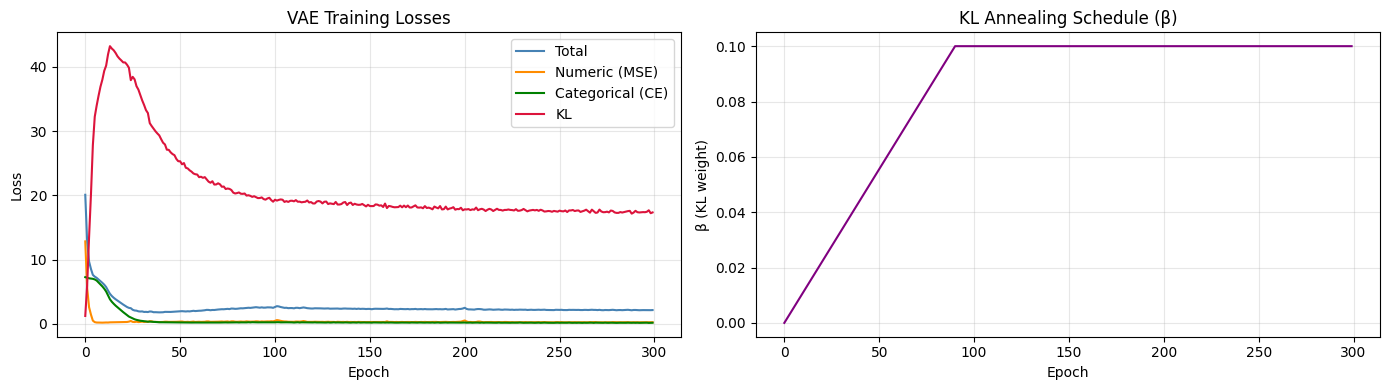

Saved → vae_training_curves.png


In [ ]:
SEED = 50
tf.random.set_seed(SEED)
np.random.seed(SEED)

vae = VAE(
    input_dim      = INPUT_DIM,
    hidden_dim     = HIDDEN_DIM,
    latent_dim     = LATENT_DIM,
    n_numeric      = N_NUMERIC,
    cat_sizes      = cat_sizes,
    numeric_weight = NUMERIC_WEIGHT,
    col_weights    = num_col_weights,
    beta_final     = BETA_FINAL,
    warmup_epochs  = KL_WARMUP_EPOCHS,
    name           = 'vae',
)
vae.compile(optimizer=keras.optimizers.Adam(LR))

print("Starting training...")
history = vae.fit(
    X_full, X_full,
    epochs     = EPOCHS,
    batch_size = BATCH_SIZE,
    shuffle    = True,
    callbacks  = [EpochCounter()],
    verbose    = 1,
)

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['total_loss'],  label='Total',            color='steelblue')
axes[0].plot(history.history['num_loss'],    label='Numeric (MSE)',    color='darkorange')
axes[0].plot(history.history['cat_loss'],    label='Categorical (CE)', color='green')
axes[0].plot(history.history['kl_loss'],     label='KL',               color='crimson')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('VAE Training Losses'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['beta'], color='purple')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('β (KL weight)')
axes[1].set_title('KL Annealing Schedule (β)'); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('vae_training_curves.png', dpi=150)
plt.show()
print("Saved → vae_training_curves.png")

**Generate Synthetic Data (posterior sampling)**

In [ ]:
# Cell 6 — Generate Synthetic Data (posterior sampling)
#
# Encode real rows → get (mu, log_var) → sample z from q(z|x) via the
# reparameterisation trick.  Posterior sampling stays close to the
# distributions the VAE learned and produces marginals that more faithfully
# match the real data than prior sampling (z ~ N(0,I)).

from scipy.special import softmax as scipy_softmax

# Freeze the NumPy RNG before any random call so results are reproducible
# across every run — mirrors torch.manual_seed(SEED) in the reference.
rng = np.random.default_rng(SEED)

# Encode real data → mu, log_var only (we build z ourselves below
# so the epsilon is drawn from the fixed NumPy RNG, not TF's stateful RNG).
mu_np      = vae.fc_mu(vae.enc_h2(vae.enc_h1(X_full))).numpy()
log_var_np = vae.fc_logvar(vae.enc_h2(vae.enc_h1(X_full))).numpy()
std_np     = np.exp(0.5 * log_var_np)

# eps drawn from the seeded NumPy generator — deterministic every run
eps         = rng.standard_normal(mu_np.shape).astype(np.float32)
z_posterior = (mu_np + std_np * eps).astype(np.float32)

raw_out = vae.decode(z_posterior, training=False).numpy()

#  Invert numeric scaling
syn_numeric = scaler.inverse_transform(raw_out[:, :N_NUMERIC])

if 'purchase_amount' in NUMERIC_COLS:
    pa_idx = NUMERIC_COLS.index('purchase_amount')
    syn_numeric[:, pa_idx] = np.clip(syn_numeric[:, pa_idx], 0, None)

#  Decode categorical via temperature-scaled softmax
cat_decoded = {}
offset = N_NUMERIC
for col, size in zip(CATEGORICAL_COLS, cat_sizes):
    logits = raw_out[:, offset : offset + size]
    probs  = scipy_softmax(logits / TEMPERATURE, axis=1)

    # Probability floor so no category is fully suppressed
    floor  = 1.0 / (size * 3)
    probs  = np.clip(probs, floor, 1.0)
    probs  = probs / probs.sum(axis=1, keepdims=True)

    chosen = np.array([rng.choice(size, p=probs[i]) for i in range(N_SYNTHETIC)])
    cat_decoded[col] = ohe.categories_[CATEGORICAL_COLS.index(col)][chosen]
    offset += size

# Assemble synthetic DataFrame
df_synthetic = pd.DataFrame(syn_numeric, columns=NUMERIC_COLS)

for col in CATEGORICAL_COLS:
    df_synthetic[col] = cat_decoded[col]

print("Synthetic Data — first 5 rows:")
display(df_synthetic.head())
print(f"\nShape: {df_synthetic.shape}")
import os

out_dir = '/content'
syn_out_path = os.path.join(out_dir, 'synthetic_customer_transactions.csv')

df_synthetic.to_csv(syn_out_path, index=False)
print(f"Saved → {syn_out_path}")

Synthetic Data — first 5 rows:


,age,annual_income,purchase_amount,gender,city,product_category,payment_method,is_returned
0,53.716702,39234.324219,78.271004,Female,Houston,Clothing,Debit Card,True
1,59.385914,123642.570312,1092.933838,Other,New York,Sports,Credit Card,True
2,21.648130,58170.109375,135.813766,Other,New York,Home,UPI,False
3,31.630344,94688.117188,532.475647,Male,Chicago,Sports,PayPal,False
4,23.350677,59002.289062,616.069153,Other,Los Angeles,Clothing,UPI,False



Shape: (1500, 8)
Saved → /content/synthetic_customer_transactions.csv


**Distribution Comparison: Real vs Synthetic**

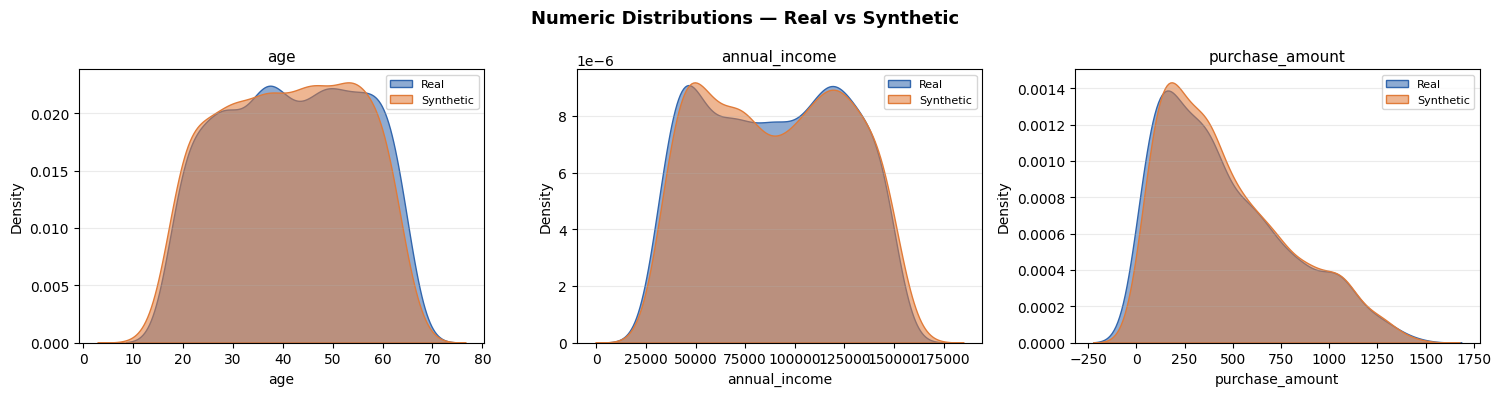

Saved → vae_numeric_distributions.png


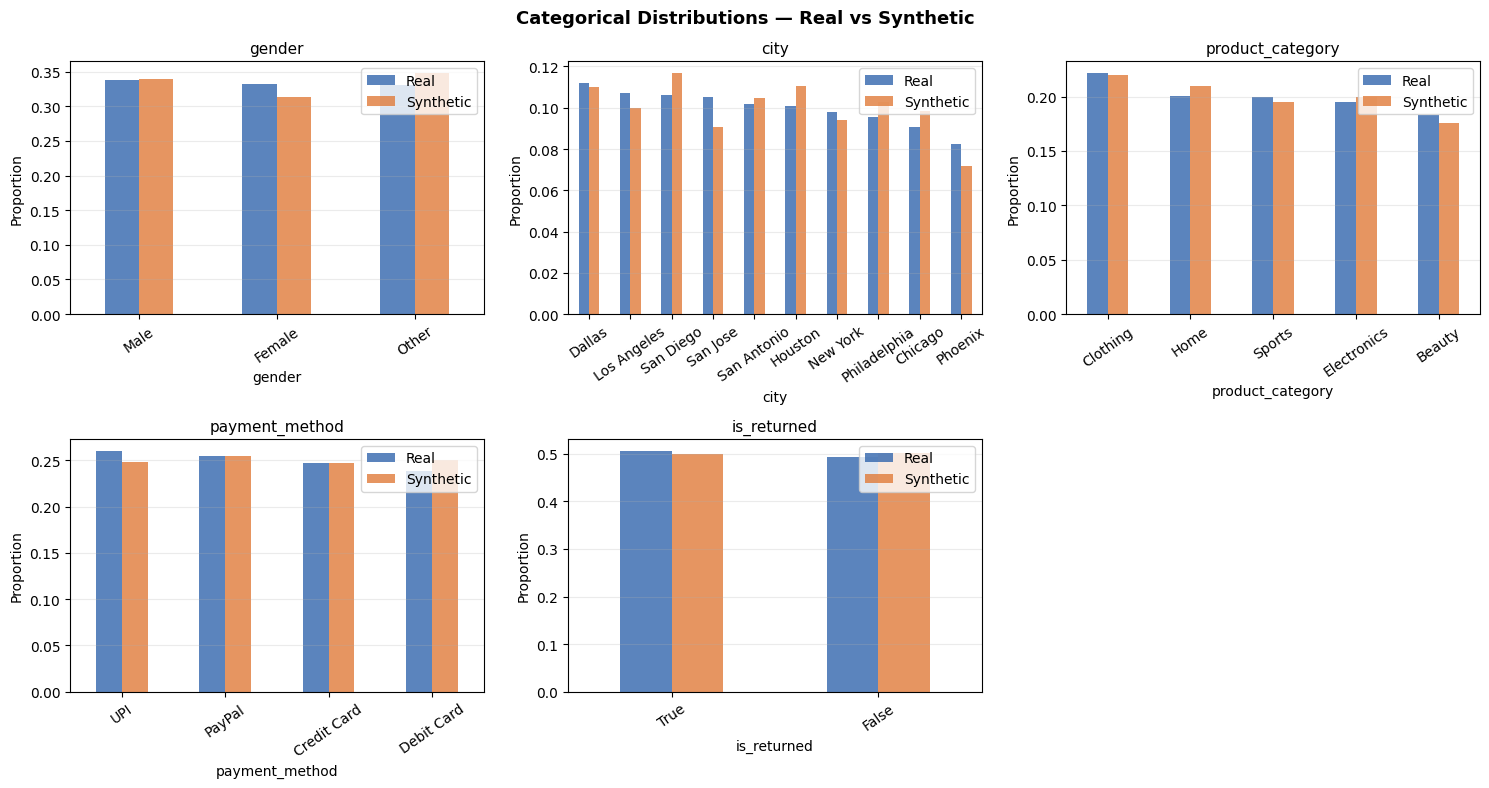

Saved → vae_categorical_distributions.png


In [ ]:
COLORS = {'real': '#3266ad', 'syn': '#e07b39'}

# Numeric: KDE overlays
if NUMERIC_COLS:
    n_cols = min(4, len(NUMERIC_COLS))
    n_rows = int(np.ceil(len(NUMERIC_COLS) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = np.array(axes).flatten() if n_rows * n_cols > 1 else [axes]

    for i, col in enumerate(NUMERIC_COLS):
        sns.kdeplot(df[col],           fill=True, label='Real',
                    ax=axes[i], color=COLORS['real'], alpha=0.55)
        sns.kdeplot(df_synthetic[col], fill=True, label='Synthetic',
                    ax=axes[i], color=COLORS['syn'],  alpha=0.55)
        axes[i].set_title(col, fontsize=11)
        axes[i].legend(fontsize=8)
        axes[i].grid(axis='y', alpha=0.25)

    for j in range(len(NUMERIC_COLS), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Numeric Distributions — Real vs Synthetic', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('vae_numeric_distributions.png', dpi=150)
    plt.show()
    print("Saved → vae_numeric_distributions.png")

# Categorical: grouped bar charts
if CATEGORICAL_COLS:
    cat_ncols = min(3, len(CATEGORICAL_COLS))
    cat_nrows = int(np.ceil(len(CATEGORICAL_COLS) / cat_ncols))
    fig, axes = plt.subplots(cat_nrows, cat_ncols,
                              figsize=(5 * cat_ncols, 4 * cat_nrows))
    axes = np.array(axes).flatten() if cat_nrows * cat_ncols > 1 else [axes]

    for i, col in enumerate(CATEGORICAL_COLS):
        r_dist = df[col].astype(str).value_counts(normalize=True).rename('Real')
        s_dist = df_synthetic[col].astype(str).value_counts(normalize=True).rename('Synthetic')
        comp   = pd.concat([r_dist, s_dist], axis=1).fillna(0)
        comp.head(10).plot(kind='bar', ax=axes[i],
                           color=[COLORS['real'], COLORS['syn']], alpha=0.8)
        axes[i].set_title(col, fontsize=11)
        axes[i].set_ylabel('Proportion')
        axes[i].tick_params(axis='x', labelrotation=35)
        axes[i].grid(axis='y', alpha=0.25)

    for j in range(len(CATEGORICAL_COLS), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Categorical Distributions — Real vs Synthetic', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('vae_categorical_distributions.png', dpi=150)
    plt.show()
    print("Saved → vae_categorical_distributions.png")

**Statistical Comparison: Real vs Synthetic (descriptive)**

In [ ]:
from scipy import stats

print("=" * 80)
print("STATISTICAL COMPARISON: ORIGINAL vs SYNTHETIC DATA")
print("=" * 80)

# Numeric columns
if NUMERIC_COLS:
    print("\n### NUMERIC COLUMNS ###\n")
    for col in NUMERIC_COLS:
        real = df[col].dropna()
        syn  = df_synthetic[col].dropna()
        rows = []
        for label, s in [("Real", real), ("Synthetic", syn)]:
            rows.append({
                "Source"   : label,
                "Count"    : s.count(),
                "Mean"     : round(s.mean(),         4),
                "Std"      : round(s.std(),          4),
                "Variance" : round(s.var(),          4),
                "Min"      : round(s.min(),          4),
                "25%"      : round(s.quantile(.25),  4),
                "Median"   : round(s.median(),       4),
                "75%"      : round(s.quantile(.75),  4),
                "Max"      : round(s.max(),          4),
                "Skewness" : round(s.skew(),         4),
                "Kurtosis" : round(s.kurt(),         4),
                "IQR"      : round(s.quantile(.75) - s.quantile(.25), 4),
            })
        stat_df = pd.DataFrame(rows).set_index("Source")
        print(f"  Column: {col}")
        display(stat_df)
        print("-" * 70)

# Categorical columns
if CATEGORICAL_COLS:
    print("\n### CATEGORICAL COLUMNS ###\n")
    for col in CATEGORICAL_COLS:
        r_s = df[col].astype(str)
        s_s = df_synthetic[col].astype(str)
        all_cats   = sorted(set(r_s.unique()) | set(s_s.unique()))
        r_counts   = r_s.value_counts()
        s_counts   = s_s.value_counts()

        rows = []
        for cat in all_cats:
            rc = int(r_counts.get(cat, 0))
            sc = int(s_counts.get(cat, 0))
            rows.append({
                "Category"        : cat,
                "Real Count"      : rc,
                "Synthetic Count" : sc,
                "Real %"          : round(rc / len(r_s) * 100, 2),
                "Synthetic %"     : round(sc / len(s_s) * 100, 2),
                "Abs Diff %"      : round(abs(rc / len(r_s) - sc / len(s_s)) * 100, 2),
            })
        cat_stat_df = pd.DataFrame(rows).set_index("Category")

        r_props = r_s.value_counts(normalize=True)
        s_props = s_s.value_counts(normalize=True)
        summary = pd.DataFrame({
            "Real"     : [r_s.nunique(), r_props.mean(), r_props.std(),
                          r_props.min(), r_props.max(),
                          stats.entropy(r_props.reindex(all_cats).fillna(0))],
            "Synthetic": [s_s.nunique(), s_props.mean(), s_props.std(),
                          s_props.min(), s_props.max(),
                          stats.entropy(s_props.reindex(all_cats).fillna(0))],
        }, index=["Unique Values", "Mean Proportion", "Std Proportion",
                  "Min Proportion", "Max Proportion", "Shannon Entropy"])

        print(f"  Column: {col}")
        print("\n  Per-category breakdown:")
        display(cat_stat_df)
        print("\n  Summary statistics:")
        display(summary.round(4))
        print("-" * 70)

print("\n" + "=" * 80)
print("END OF STATISTICAL COMPARISON")
print("=" * 80)

STATISTICAL COMPARISON: ORIGINAL vs SYNTHETIC DATA

### NUMERIC COLUMNS ###

  Column: age


,Count,Mean,Std,Variance,Min,25%,Median,75%,Max,Skewness,Kurtosis,IQR
Source,,,,,,,,,,,,
Real,1500,41.832000,13.5193,182.7723,18.0000,30.0000,42.0000,53.0000,65.0000,-0.0467,-1.1630,23.0000
Synthetic,1500,40.943501,13.4310,180.3923,12.1341,29.6199,41.3909,52.5602,67.3404,-0.0534,-1.1264,22.9403


----------------------------------------------------------------------
  Column: annual_income


,Count,Mean,Std,Variance,Min,25%,Median,75%,Max,Skewness,Kurtosis,IQR
Source,,,,,,,,,,,,
Real,1500,89370.856000,34986.7363,1.224072e+09,30011.0000,57964.2500,89676.0000,119895.5000,149822.0000,0.0003,-1.2537,61931.2500
Synthetic,1500,90545.460938,35189.6680,1.238313e+09,23836.7578,58778.7246,90904.4922,120608.7754,160577.7031,0.0299,-1.2392,61830.0508


----------------------------------------------------------------------
  Column: purchase_amount


...

----------------------------------------------------------------------
  Column: is_returned

  Per-category breakdown:


,Real Count,Synthetic Count,Real %,Synthetic %,Abs Diff %
Category,,,,,
False,741,751,49.4,50.07,0.67
True,759,749,50.6,49.93,0.67



  Summary statistics:


,Real,Synthetic
Unique Values,2.0000,2.0000
Mean Proportion,0.5000,0.5000
Std Proportion,0.0085,0.0009
Min Proportion,0.4940,0.4993
Max Proportion,0.5060,0.5007
Shannon Entropy,0.6931,0.6931


----------------------------------------------------------------------

END OF STATISTICAL COMPARISON


# Extended Statistical Validation: Real vs Synthetic

Formal hypothesis tests quantify how closely the synthetic data reproduces the original distributions.

**Numeric columns** (three complementary tests):
- **Welch t-test** — equality of means (robust to unequal variances)
- **Kolmogorov–Smirnov (KS) test** — compares the full empirical CDFs
- **Levene test** — equality of variances / spread

**Categorical columns**:
- **Chi-square test** — compares observed category proportions

A column **passes** when **all** applicable tests yield p ≥ 0.05 — meaning we cannot statistically distinguish the synthetic distribution from the real one on that dimension.

**1. Numeric columns — descriptive statistics**

In [ ]:
print('=== REAL data — numeric describe ===')
print(df[NUMERIC_COLS].describe().round(2).to_string())
print()
print('=== SYNTHETIC data — numeric describe ===')
print(df_synthetic[NUMERIC_COLS].describe().round(2).to_string())

=== REAL data — numeric describe ===
           age  annual_income  purchase_amount
count  1500.00        1500.00          1500.00
mean     41.83       89370.86           451.59
std      13.52       34986.74           330.78
min      18.00       30011.00             7.26
25%      30.00       57964.25           178.70
50%      42.00       89676.00           374.66
75%      53.00      119895.50           665.84
max      65.00      149822.00          1456.04

=== SYNTHETIC data — numeric describe ===
           age  annual_income  purchase_amount
count  1500.00        1500.00          1500.00
mean     40.94       90545.46           463.58
std      13.43       35189.67           323.87
min      12.13       23836.76             1.03
25%      29.62       58778.72           197.04
50%      41.39       90904.49           383.42
75%      52.56      120608.78           666.17
max      67.34      160577.70          1451.93


**2. Welch t-test — comparing means**

In [ ]:
header = (f"{'Column':<20} {'Real mean':>12} {'Syn mean':>12} {'% diff':>8} "
          f"{'t-stat':>10} {'p-value':>10} {'Significant?':>14}")
print(header)
print('-' * 90)

ttest_rows = []
for col in NUMERIC_COLS:
    r_mean = df[col].mean()
    s_mean = df_synthetic[col].mean()
    pct    = abs(r_mean - s_mean) / r_mean * 100 if r_mean != 0 else 0.0
    t, p   = sp_stats.ttest_ind(df[col].dropna(), df_synthetic[col].dropna(), equal_var=False)
    sig    = '*** YES' if p < 0.05 else 'no'
    print(f'{col:<20} {r_mean:>12.2f} {s_mean:>12.2f} {pct:>7.1f}% {t:>10.4f} {p:>10.4f} {sig:>14}')
    ttest_rows.append({
        'column': col, 'real_mean': round(r_mean, 4), 'syn_mean': round(s_mean, 4),
        'pct_diff': round(pct, 4), 't_stat': round(t, 4), 'p_value': round(p, 4),
        'significant': sig.strip(),
    })

ttest_df = pd.DataFrame(ttest_rows)
display(ttest_df)

Column                  Real mean     Syn mean   % diff     t-stat    p-value   Significant?
------------------------------------------------------------------------------------------
age                         41.83        40.94     2.1%     1.8057     0.0711             no
annual_income            89370.86     90545.46     1.3%    -0.9168     0.3593             no
purchase_amount            451.59       463.58     2.7%    -1.0034     0.3158             no


,column,real_mean,syn_mean,pct_diff,t_stat,p_value,significant
0,age,41.8320,40.943501,2.1240,1.8057,0.0711,no
1,annual_income,89370.8560,90545.460938,1.3143,-0.9168,0.3593,no
2,purchase_amount,451.5886,463.581909,2.6558,-1.0034,0.3158,no


**3. Extended numeric similarity tests — KS and Levene**

The t-test only checks means. The KS test compares the full CDF shape; the Levene test checks variance equality. Together they catch mismatches that means alone would miss.

In [ ]:
print('=' * 85)
header2 = (f"{'Column':<20} | {'KS stat':>8} {'KS p':>8} {'KS sig':>8} | "
           f"{'Levene F':>9} {'Lev p':>8} {'Lev sig':>8}")
print(header2)
print('-' * 85)

ext_rows = []
for col in NUMERIC_COLS:
    a = df[col].dropna().values
    b = df_synthetic[col].dropna().values
    ks_s,  ks_p  = ks_2samp(a, b)
    lev_s, lev_p = levene(a, b)
    ks_sig  = '*** YES' if ks_p  < 0.05 else 'no'
    lev_sig = '*** YES' if lev_p < 0.05 else 'no'
    print(f'{col:<20} | {ks_s:>8.4f} {ks_p:>8.4f} {ks_sig:>8} | '
          f'{lev_s:>9.4f} {lev_p:>8.4f} {lev_sig:>8}')
    ext_rows.append({
        'column': col,
        'ks_stat': round(ks_s, 4),   'ks_p': round(ks_p, 4),   'ks_significant': ks_sig.strip(),
        'levene_stat': round(lev_s, 4), 'levene_p': round(lev_p, 4), 'levene_significant': lev_sig.strip(),
    })

print('=' * 85)
print()
print('Interpretation:')
print('  KS test    — p < 0.05: distribution shapes differ')
print('  Levene test — p < 0.05: variances differ')
ext_df = pd.DataFrame(ext_rows)
display(ext_df)

Column               |  KS stat     KS p   KS sig |  Levene F    Lev p  Lev sig
-------------------------------------------------------------------------------------
age                  |   0.0427   0.1303       no |    0.1853   0.6668       no
annual_income        |   0.0273   0.6298       no |    0.1860   0.6663       no
purchase_amount      |   0.0433   0.1196       no |    0.6832   0.4086       no

Interpretation:
  KS test    — p < 0.05: distribution shapes differ
  Levene test — p < 0.05: variances differ


,column,ks_stat,ks_p,ks_significant,levene_stat,levene_p,levene_significant
0,age,0.0427,0.1303,no,0.1853,0.6668,no
1,annual_income,0.0273,0.6298,no,0.1860,0.6663,no
2,purchase_amount,0.0433,0.1196,no,0.6832,0.4086,no


**4. Numeric column visualisations**

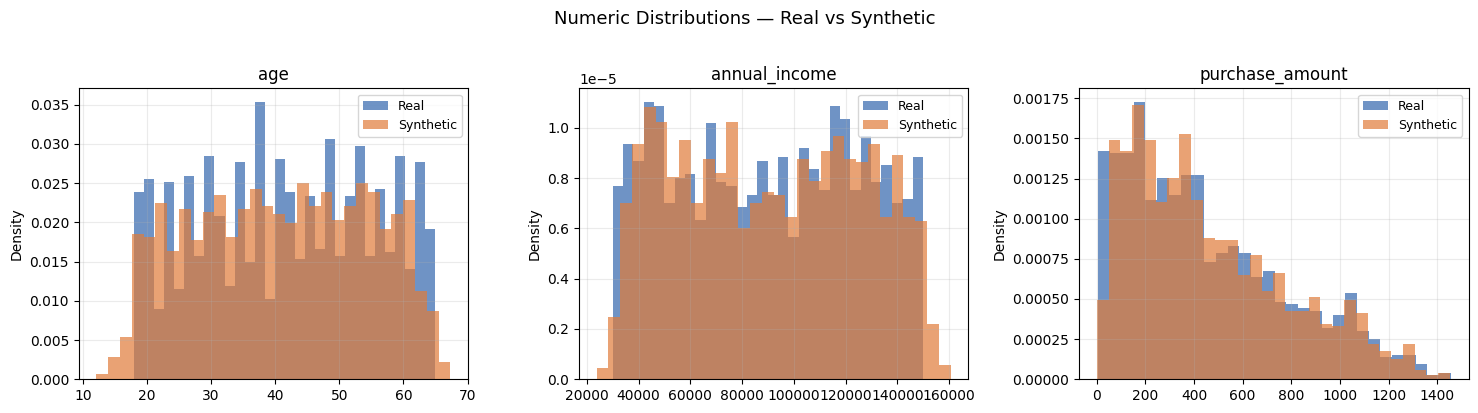

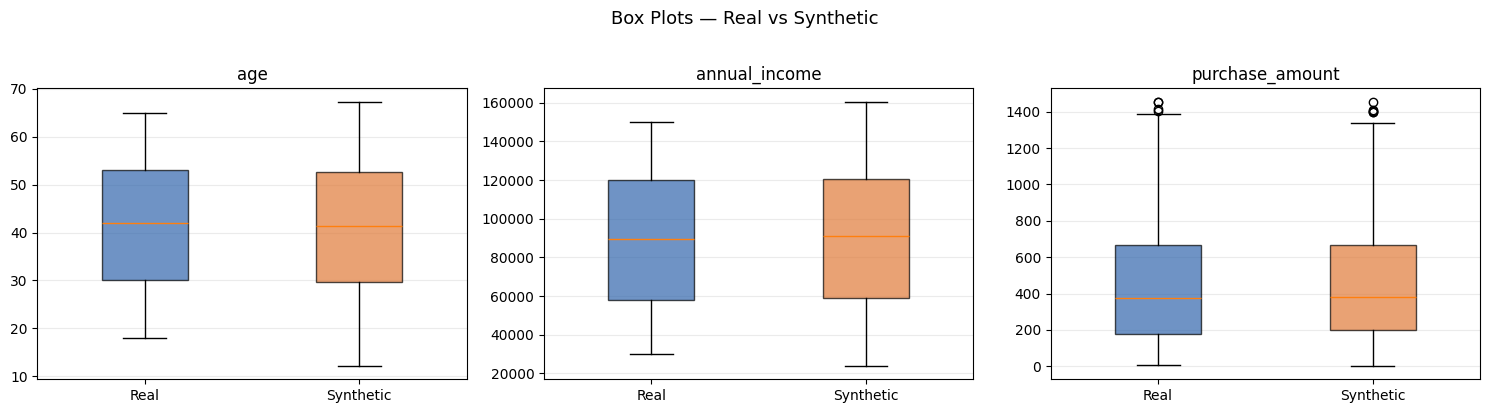

Saved → vae_boxplots.png


In [ ]:
# Histogram overlays
fig, axes = plt.subplots(1, len(NUMERIC_COLS), figsize=(5 * len(NUMERIC_COLS), 4))
if len(NUMERIC_COLS) == 1:
    axes = [axes]

for ax, col in zip(axes, NUMERIC_COLS):
    ax.hist(df[col].dropna(),           bins=30, alpha=0.7,
            color=COLORS['real'], label='Real',      density=True)
    ax.hist(df_synthetic[col].dropna(), bins=30, alpha=0.7,
            color=COLORS['syn'],  label='Synthetic', density=True)
    ax.set_title(col, fontsize=12)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25)

fig.suptitle('Numeric Distributions — Real vs Synthetic', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Box plots — spread comparison
fig, axes = plt.subplots(1, len(NUMERIC_COLS), figsize=(5 * len(NUMERIC_COLS), 4))
if len(NUMERIC_COLS) == 1:
    axes = [axes]

for ax, col in zip(axes, NUMERIC_COLS):
    bp = ax.boxplot(
        [df[col].dropna(), df_synthetic[col].dropna()],
        patch_artist=True, labels=['Real', 'Synthetic'], widths=0.4,
    )
    for patch, color in zip(bp['boxes'], [COLORS['real'], COLORS['syn']]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(col, fontsize=12)
    ax.grid(axis='y', alpha=0.25)

fig.suptitle('Box Plots — Real vs Synthetic', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('vae_boxplots.png', dpi=150)
plt.show()
print("Saved → vae_boxplots.png")

5. Categorical columns — chi-square test

In [ ]:
header3 = f"{'Column':<20} {'chi2':>10} {'p-value':>10} {'dof':>5} {'Significant?':>14}"
print(header3)
print('-' * 65)

chi_rows = []
for col in CATEGORICAL_COLS:
    all_vals = sorted(set(df[col].astype(str).unique()) |
                      set(df_synthetic[col].astype(str).unique()), key=str)
    r_cnt = [int(df[col].astype(str).value_counts().get(v, 0))           for v in all_vals]
    s_cnt = [int(df_synthetic[col].astype(str).value_counts().get(v, 0)) for v in all_vals]
    cont  = np.vstack([r_cnt, s_cnt])
    mask  = cont.sum(axis=0) > 0
    chi2, p, dof, _ = sp_stats.chi2_contingency(cont[:, mask])
    sig = '*** YES' if p < 0.05 else 'no'
    print(f'{col:<20} {chi2:>10.4f} {p:>10.4f} {dof:>5} {sig:>14}')
    chi_rows.append({
        'column': col, 'chi2': round(chi2, 4), 'p_value': round(p, 4),
        'dof': int(dof), 'significant': sig.strip(),
    })

chi_df = pd.DataFrame(chi_rows)
display(chi_df)

Column                     chi2    p-value   dof   Significant?
-----------------------------------------------------------------
gender                   1.4792     0.4773     2             no
city                     5.7331     0.7663     9             no
product_category         0.6270     0.9600     4             no
payment_method           0.8208     0.8445     3             no
is_returned              0.1080     0.7424     1             no


,column,chi2,p_value,dof,significant
0,gender,1.4792,0.4773,2,no
1,city,5.7331,0.7663,9,no
2,product_category,0.6270,0.9600,4,no
3,payment_method,0.8208,0.8445,3,no
4,is_returned,0.1080,0.7424,1,no


**6. Categorical column visualisations**

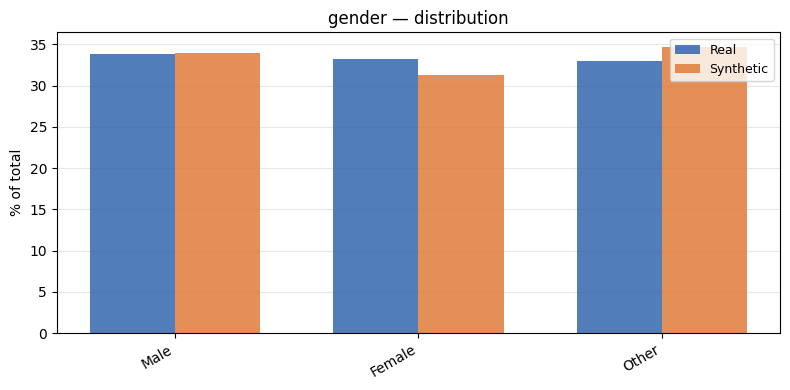

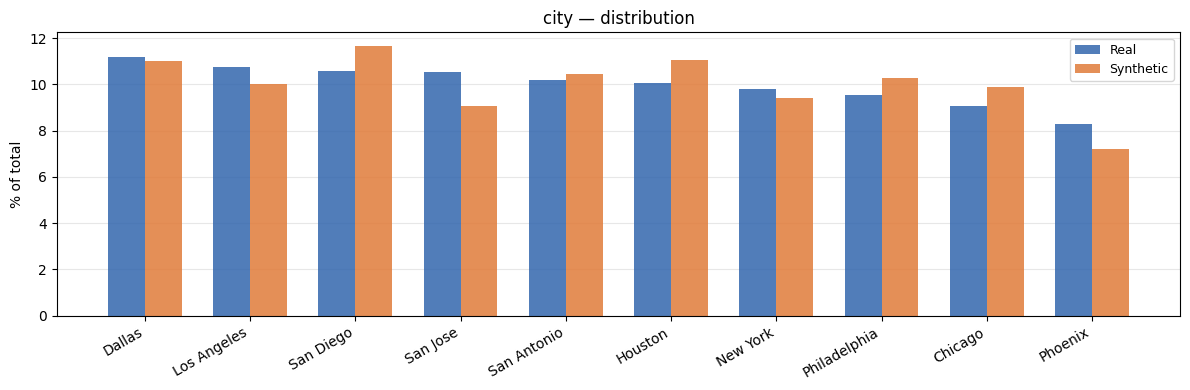

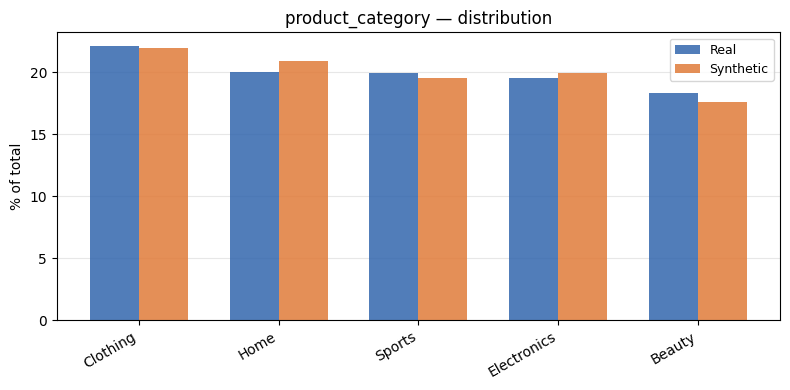

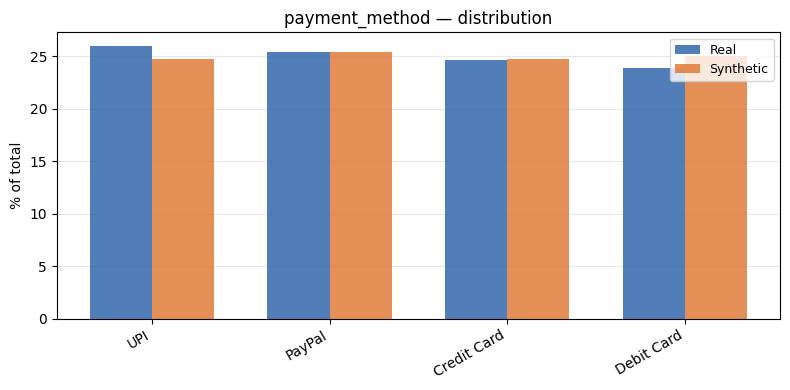

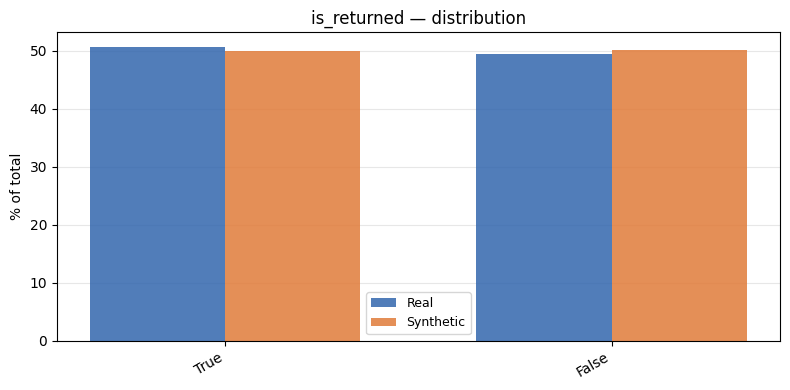

In [ ]:
for col in CATEGORICAL_COLS:
    r_dist  = df[col].astype(str).value_counts(normalize=True).mul(100).rename('Real')
    s_dist  = df_synthetic[col].astype(str).value_counts(normalize=True).mul(100).rename('Synthetic')
    df_plot = pd.concat([r_dist, s_dist], axis=1).fillna(0).sort_values('Real', ascending=False)

    x, w = np.arange(len(df_plot)), 0.35
    fig, ax = plt.subplots(figsize=(max(8, len(df_plot) * 1.2), 4))
    ax.bar(x - w/2, df_plot['Real'],      w, label='Real',
           color=COLORS['real'], alpha=0.85)
    ax.bar(x + w/2, df_plot['Synthetic'], w, label='Synthetic',
           color=COLORS['syn'],  alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(df_plot.index, rotation=30, ha='right', fontsize=10)
    ax.set_ylabel('% of total', fontsize=10)
    ax.set_title(f'{col} — distribution', fontsize=12)
    ax.legend(fontsize=9)
    ax.yaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

**7. Combined test summary**

One row per column. A row **passes** when all applicable tests yield p ≥ 0.05, meaning the synthetic distribution is statistically indistinguishable from the real one on means, shape, spread, and category proportions.

In [ ]:
summary_rows = []
for col in NUMERIC_COLS:
    r = df[col].dropna().values
    s = df_synthetic[col].dropna().values

    t,   t_p   = sp_stats.ttest_ind(r, s, equal_var=False)
    _,   ks_p  = ks_2samp(r, s)
    _,   lev_p = levene(r, s)

    passed = (t_p >= 0.05) and (ks_p >= 0.05) and (lev_p >= 0.05)

    summary_rows.append({
        'column'      : col,
        'type'        : 'numeric',
        'real_summary': f'mean={r.mean():.2f}, std={r.std():.2f}',
        'syn_summary' : f'mean={s.mean():.2f}, std={s.std():.2f}',
        't_p'         : round(t_p,   4),
        'ks_p'        : round(ks_p,  4),
        'levene_p'    : round(lev_p, 4),
        'chi2_p'      : '-',
        'overall'     : 'PASS' if passed else 'FAIL',
    })

for col in CATEGORICAL_COLS:
    all_vals = sorted(
        set(df[col].astype(str).unique()) |
        set(df_synthetic[col].astype(str).unique()),
        key=str
    )

    r_cnt = [int(df[col].astype(str).value_counts().get(v, 0)) for v in all_vals]
    s_cnt = [int(df_synthetic[col].astype(str).value_counts().get(v, 0)) for v in all_vals]

    cont  = np.vstack([r_cnt, s_cnt])
    mask  = cont.sum(axis=0) > 0

    _, chi_p, _, _ = sp_stats.chi2_contingency(cont[:, mask])

    passed = chi_p >= 0.05

    summary_rows.append({
        'column'      : col,
        'type'        : 'categorical',
        'real_summary': f"mode={df[col].mode()[0]} ({df[col].nunique()} unique)",
        'syn_summary' : f"mode={df_synthetic[col].mode()[0]} ({df_synthetic[col].nunique()} unique)",
        't_p'         : '-',
        'ks_p'        : '-',
        'levene_p'    : '-',
        'chi2_p'      : round(chi_p, 4),
        'overall'     : 'PASS' if passed else 'FAIL',
    })

summary_df = pd.DataFrame(summary_rows)

# test summary
import os

out_dir = '/content'
summary_path = os.path.join(out_dir, 'test_summary_real_vs_synthetic.csv')

summary_df.to_csv(summary_path, index=False)

print('=' * 100)
print('FINAL TEST SUMMARY — Real vs Synthetic')
print('=' * 100)
display(summary_df)

n_num   = (summary_df['type'] == 'numeric').sum()
n_cat   = (summary_df['type'] == 'categorical').sum()

n_num_p = ((summary_df['type'] == 'numeric') &
           (summary_df['overall'] == 'PASS')).sum()

n_cat_p = ((summary_df['type'] == 'categorical') &
           (summary_df['overall'] == 'PASS')).sum()

n_total = len(summary_df)
n_pass  = (summary_df['overall'] == 'PASS').sum()

print()
print(f'Numeric columns     : {n_num_p}/{n_num} passed all tests (t-test, KS, Levene)')
print(f'Categorical columns : {n_cat_p}/{n_cat} passed chi-square')
print(f'Overall             : {n_pass}/{n_total} columns indistinguishable from real (p >= 0.05 on every test)')
print()
print(f'Saved -> {summary_path}')

FINAL TEST SUMMARY — Real vs Synthetic


,column,type,real_summary,syn_summary,t_p,ks_p,levene_p,chi2_p,overall
0,age,numeric,"mean=41.83, std=13.51","mean=40.94, std=13.43",0.0711,0.1303,0.6668,-,PASS
1,annual_income,numeric,"mean=89370.86, std=34975.07","mean=90545.46, std=35177.94",0.3593,0.6298,0.6663,-,PASS
2,purchase_amount,numeric,"mean=451.59, std=330.67","mean=463.58, std=323.76",0.3158,0.1196,0.4086,-,PASS
3,gender,categorical,mode=Male (3 unique),mode=Other (3 unique),-,-,-,0.4773,PASS
4,city,categorical,mode=Dallas (10 unique),mode=San Diego (10 unique),-,-,-,0.7663,PASS
5,product_category,categorical,mode=Clothing (5 unique),mode=Clothing (5 unique),-,-,-,0.96,PASS
6,payment_method,categorical,mode=UPI (4 unique),mode=PayPal (4 unique),-,-,-,0.8445,PASS
7,is_returned,categorical,mode=True (2 unique),mode=False (2 unique),-,-,-,0.7424,PASS



Numeric columns     : 3/3 passed all tests (t-test, KS, Levene)
Categorical columns : 5/5 passed chi-square
Overall             : 8/8 columns indistinguishable from real (p >= 0.05 on every test)

Saved -> /content/test_summary_real_vs_synthetic.csv
